# 🏢 Unidad 3 · Clase 4 — Laboratorio Práctico Dirigido
## Resolución de Caso Real: Predicción de Rotación de Empleados (HR Attrition)

---

## El problema de negocio

**Cliente:** IBM — División de Recursos Humanos  
**Problema:** La empresa pierde talento clave sin anticiparlo. Cada vez que un empleado renuncia, IBM incurre en costos de reclutamiento, onboarding y pérdida de conocimiento institucional. Estudios del sector estiman que reemplazar a un empleado cuesta entre **50% y 200% de su salario anual**.

**Pregunta de negocio:**  
> *"¿Podemos predecir qué empleados tienen mayor probabilidad de renunciar en los próximos meses, para que el equipo de RRHH pueda intervenir proactivamente?"*

**Lo que el cliente espera recibir:**
1. Un modelo que identifique empleados en riesgo de renuncia
2. Las variables que más influyen en la decisión de irse
3. Métricas que le permitan entender los errores del modelo y sus consecuencias
4. Recomendaciones accionables basadas en los hallazgos

---

## El dataset: IBM HR Analytics Employee Attrition

Dataset real publicado por IBM con **1 470 registros** de empleados activos y ex-empleados.

| Dimensión | Detalle |
|---|---|
| **Filas** | 1 470 empleados |
| **Columnas** | 35 variables (demográficas, laborales, de satisfacción) |
| **Target** | `Attrition`: Yes (renuncia) / No (se queda) |
| **Nulos** | 0 — dataset limpio |
| **Desbalance** | 237 renuncias (16.1%) vs 1 233 que se quedan (83.9%) |

### ⚠️ El desafío del desbalance de clases

Este es el problema más crítico del dataset. Si entrenáramos un modelo que **siempre predice "No renuncia"**, obtendríamos **83.9% de accuracy**... sin aprender absolutamente nada.

Por eso en esta clase la **Accuracy es insuficiente**. Necesitamos:
- **Recall** de la clase "Yes": ¿de todos los que realmente renuncian, cuántos detectamos?
- **Precision** de la clase "Yes": de los que predecimos que renuncian, ¿cuántos realmente lo hacen?
- **F1-Score**: balance entre Precision y Recall

> ⚠️ Un **Falso Negativo** (predecir "No renuncia" cuando sí va a renunciar) es el error más costoso para el cliente: el empleado se va sin que nadie lo anticipara.

---

## ¿Qué construiremos hoy?

```
Dataset IBM HR Attrition (1470 empleados)
        │
        ├─ EDA: entender el problema de negocio con datos
        ├─ Preprocesamiento: limpieza, encoding, escalado
        ├─ Modelo 1: Random Forest
        ├─ Modelo 2: Regresión Logística
        ├─ Evaluación Pro: Precision, Recall, F1, Confusion Matrix
        ├─ Cross-Validation K-Fold: estimación robusta de performance
        ├─ GridSearchCV: optimización de hiperparámetros
        └─ Informe técnico: conclusiones para el cliente
```

## Manos a la obra

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

#Metricas de evaluación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

#validación y optimizacion
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.pipeline import Pipeline

In [40]:
#Carga de datos
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'Dimensiones del dataset: {df.shape[0]:,} empleados x {df.shape[1]} variables')
print()
df.head(4)

Dimensiones del dataset: 1,470 empleados x 35 variables



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0


In [41]:
#Descripcion general del dataste

print("Tipos de datos por columna:")
print(df.dtypes.to_string())
print()

print("Columnas con un solo valor único (constantes ----> Elimnar)")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f' {col}. siempre = {df[col].unique()[0]}')

Tipos de datos por columna:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears   

In [42]:
conteo_target = df['Attrition'].value_counts()
pct_target    = df['Attrition'].value_counts(normalize=True)

resumen_target = pd.DataFrame({
    'Empleado': conteo_target,
    'Porcentaje': (pct_target * 100).round(1)
})

print('Dsitribución del target')
print(resumen_target)
print()
print(f'Ratio de desbalance: 1: {conteo_target["No"] // conteo_target["Yes"]} (No:Yes)')
print()


Dsitribución del target
           Empleado  Porcentaje
Attrition                      
No             1233        83.9
Yes             237        16.1

Ratio de desbalance: 1: 5 (No:Yes)



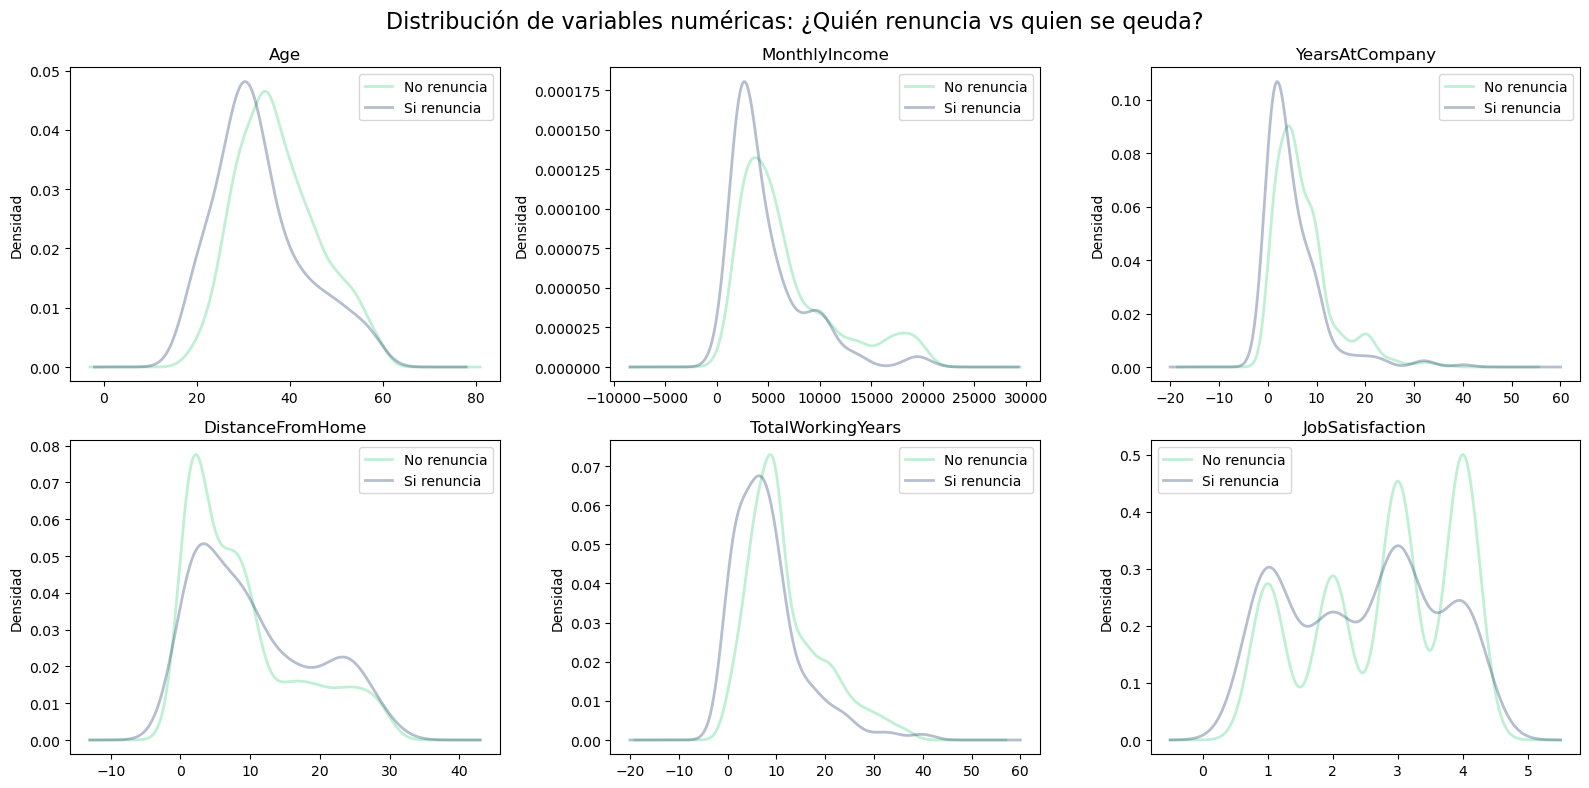

In [43]:
#Variables numércias clase: ¿Qué diferencia a los que renuncian

vars_numericas_eda = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome', 
                      'TotalWorkingYears', 'JobSatisfaction']

fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(vars_numericas_eda):
    grupo_no  = df[df['Attrition'] == 'No'][col]
    grupo_yes = df[df['Attrition'] == 'Yes'][col]
    
    grupo_no.plot.kde(ax=axes[i], label='No renuncia', color='#2ecc71', linewidth=2, alpha=0.3)
    grupo_yes.plot.kde(ax=axes[i], label='Si renuncia', color="#0C295F", linewidth=2, alpha=0.3)
    
    axes[i].set_title(f'{col}')
    axes[i].legend(fontsize=10)
    axes[i].set_ylabel('Densidad')
    

fig.suptitle('Distribución de variables numéricas: ¿Quién renuncia vs quien se qeuda?', fontsize=16)
plt.tight_layout()
plt.show()

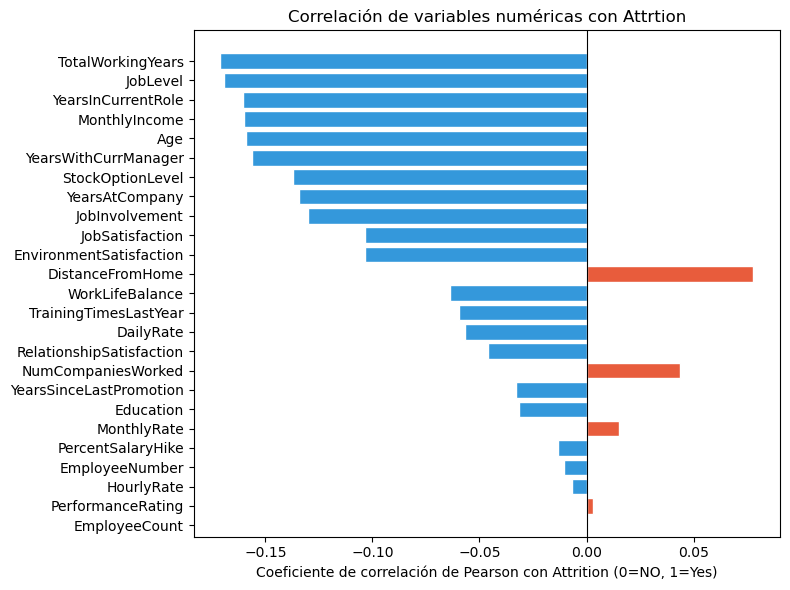

In [44]:
df_corr = df.copy()

df_corr['Attrition_num'] = (df_corr['Attrition'] == 'Yes').astype(int)

cols_num = df_corr.select_dtypes(include='number').columns.tolist()

corr_con_target = (df_corr[cols_num]
                   .corr()['Attrition_num']
                   .drop('Attrition_num')
                   .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
colores_corr = ['#e85c3c' if v > 0 else '#3498db' for v in corr_con_target]
ax.barh(corr_con_target.index[::-1], corr_con_target.values[::-1],
        color=colores_corr[::-1], edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables numéricas con Attrtion')

ax.set_xlabel('Coeficiente de correlación de Pearson con Attrition (0=NO, 1=Yes)')
plt.tight_layout()
plt.show()

## Prepocesamiento --------------> Preparar el dataset para ML

In [49]:
#Por que no hace falta escalar para Random Forest?

df_clean = df.copy()

cols_eliminar = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df_clean.drop(columns=cols_eliminar)

print(f'Columnas despues de eliminar constantes e IDs: {df_clean.shape[1]}')

#Conversión el target a binario
df_clean['Attrition'] = (df_clean['Attrition'] == 'Yes').astype(int)

#verify
print(f'valores únicos en Atrition depsues de conversión: {df_clean["Attrition"].unique()}')

Columnas despues de eliminar constantes e IDs: 31
valores únicos en Atrition depsues de conversión: [1 0]


In [56]:
#Encoding de variables categóricas 

cols_categoricas = df_clean.select_dtypes(include='object').columns.tolist()
print('Variables categóricas a codificar:')
for col in cols_categoricas:
    print(f' {col}: {df_clean[col].unique()[:5]}...')
print()

# Variables binarias : --> LabelEncoder
le = LabelEncoder()
for col in ['Gender', 'OverTime']:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f'{col}: codificado con LabelEncoder --> Valores únicos: {df_clean[col].unique()}')
print()

#Variables nominales
cols_ohe = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_clean = pd.get_dummies(df_clean, columns=cols_ohe, drop_first=True, dtype=int)

print(f'Columnas totales después de OHE: {df_clean.shape[1]}')
print(f'Nuevas columnas OHE creadas: {df_clean.shape[1] -31}')


Variables categóricas a codificar:
 BusinessTravel: <ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str...
 Department: <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str...
 EducationField: <ArrowStringArray>
['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree']
Length: 5, dtype: str...
 JobRole: <ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative']
Length: 5, dtype: str...
 MaritalStatus: <ArrowStringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str...

Gender: codificado con LabelEncoder --> Valores únicos: [0 1]
OverTime: codificado con LabelEncoder --> Valores únicos: [1 0]

Columnas totales después de OHE: 45
Nuevas columnas OHE creadas: 14


C:\Users\JORGE\AppData\Local\Temp\ipykernel_18752\2201284342.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_clean.select_dtypes(include='object').columns.tolist()


## Separación de Features (X) y target (y)



In [58]:
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

#División real y estratificada 80/20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]:,} empleados | Prueba: {X_test.shape[0]:,} empleados')
print(f'Tasa de renuncia en train: {y_train.mean():.1%}')
print(f'Tasa de renuncia en test: {y_test.mean():.1%}')

Entrenamiento: 1,176 empleados | Prueba: 294 empleados
Tasa de renuncia en train: 16.2%
Tasa de renuncia en test: 16.0%


## MODELO 1: RANDOM FOREST

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Random Forest entrenado con 200 árboles y clas_weight=balanced')
print(f' Accuracy en Prueba: {accuracy_score(y_test, y_pred_rf):1%}')

Random Forest entrenado con 200 árboles y clas_weight=balanced
 Accuracy en Prueba: 83.673469%


## Random Forest = Accuracy en Prueba: 83.673469%

### Modelo 2 : Regresión Logística


In [64]:
#pipeline = La forma correcta de escalar con validación cruzadas 

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=1.0,
        random_state=42
    ))
])

pipeline_lr.fit(X_train, y_train)

y_pred_lr = pipeline_lr.predict(X_test)

y_prob_lr = pipeline_lr.predict_proba(X_test)[:,1]

print("Pipeline (StandardScaler + LogisticRegression) entrenado")
print(f' Accuracy en prueba: {accuracy_score(y_test, y_pred_lr):1%}')
    

Pipeline (StandardScaler + LogisticRegression) entrenado
 Accuracy en prueba: 75.170068%


In [70]:
#Reportes de clasificación

print('='*55)
print('Modelo 1 - Random Forest')
print('='*55)

print(classification_report(y_test, y_pred_rf,
                            target_names=['No renucia (0)', 'Si renuncia (1)' ]))

print()
print('='*55)
print('Modelo 2 - Regresión Logística')
print('='*55)

print(classification_report(y_test, y_pred_lr,
                            target_names=['No renucia (0)', 'Si renuncia (1)' ]))

Modelo 1 - Random Forest
                 precision    recall  f1-score   support

 No renucia (0)       0.85      0.98      0.91       247
Si renuncia (1)       0.44      0.09      0.14        47

       accuracy                           0.84       294
      macro avg       0.65      0.53      0.53       294
   weighted avg       0.78      0.84      0.79       294


Modelo 2 - Regresión Logística
                 precision    recall  f1-score   support

 No renucia (0)       0.91      0.78      0.84       247
Si renuncia (1)       0.35      0.62      0.44        47

       accuracy                           0.75       294
      macro avg       0.63      0.70      0.64       294
   weighted avg       0.82      0.75      0.78       294

